# Music Genre Recognition: KNN vs Vanilla RNN vs Bi-LSTM

Final project for EE559

Nomaan A. Kherani

We compare three approaches to music genre classification on
the GTZAN dataset:
 1. **K-Nearest Neighbors** (implemented from scratch) using the mean and
    variance of 13 MFCCs as features.
 2. **Vanilla RNN** (implemented from scratch using PyTorch tensors and
    autograd, but with a manually written RNN cell) using 13 MFCCs over time.
 3. **Bidirectional LSTM** (`torch.nn.LSTM`) using 13 MFCCs over time.

## 1. Setup

In [28]:
!pip install -q librosa==0.10.2 datasets==3.6.0

In [29]:
import os
import time
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, f1_score)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from datasets import load_dataset

rng = 42
np.random.seed(rng)
torch.manual_seed(rng)
torch.cuda.manual_seed_all(rng)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

os.makedirs('figures', exist_ok=True)

cpu


## 2. Load the GTZAN dataset

We get the dataset from HuggingFace. It has 1000 thirty-second clips
with 100 clips from each of the 10 genres. One file (`jazz.00054.wav`) is known to be
corrupted and is removed in the HuggingFace dataset

In [30]:
ds = load_dataset("marsyas/gtzan", "all", trust_remote_code=True)
print(ds)

genres = ds['train'].features['genre'].names
n = len(genres)
print("Genres: " + str(genres))

DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'genre'],
        num_rows: 999
    })
})
Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


## 3. Feature extraction

We extract 13 MFCCs from each clip with the `librosa` library. We use a hop length of
2048 and a sampling rate of 22050. Thus, the resulting sequence is short
enough for the vanilla RNN. Each clip becomes a sequence
of 300 time steps. Clips that are too short are zero-padded
and clips that are too long are truncated.

- For **KNN** we collapse the time axis: 13 means and 13 variances per
  clip (26 features total).
- For the **RNN models** we keep the full (300, 13) sequence.

In [31]:
SR = 22050
nmfcc = 13
nfft = 2048
hop = 2048
maxlen = 300


def extract_mfcc(audio, sr):
    audio = np.asarray(audio).astype(np.float32)
    if sr != SR:
        audio = librosa.resample(y=audio, orig_sr=sr, target_sr=SR)
    mfcc = librosa.feature.mfcc(y=audio, sr=SR, n_mfcc=nmfcc,n_fft=nfft, hop_length=hop)    # (nmfcc, T)
    if mfcc.shape[1] < maxlen:
        mfcc = np.pad(mfcc, ((0, 0), (0, maxlen - mfcc.shape[1])))
    else:
        mfcc = mfcc[:, :maxlen]
    return mfcc.T.astype(np.float32)  # (maxlen, nmfcc)


def summary_features(mfcc_seq):
    return np.concatenate([mfcc_seq.mean(axis=0), mfcc_seq.var(axis=0)]).astype(np.float32)


def process_all(dataset):
    seqs, sums, labels = [], [], []
    for i, sample in enumerate(dataset):
        audio = sample['audio']['array']
        sr = sample['audio']['sampling_rate']
        label = sample['genre']
        mfcc_seq = extract_mfcc(audio, sr)
        seqs.append(mfcc_seq)
        sums.append(summary_features(mfcc_seq))
        labels.append(label)
    return (np.stack(seqs), np.stack(sums), np.array(labels))

X_seq, X_sum, y = process_all(ds['train'])
print(f"X_seq shape: {X_seq.shape}")
print(f"X_sum shape: {X_sum.shape}")
print(f"y     shape: {y.shape}")

X_seq shape: (999, 300, 13)
X_sum shape: (999, 26)
y     shape: (999,)


## 4. Exploratory Data Analysis

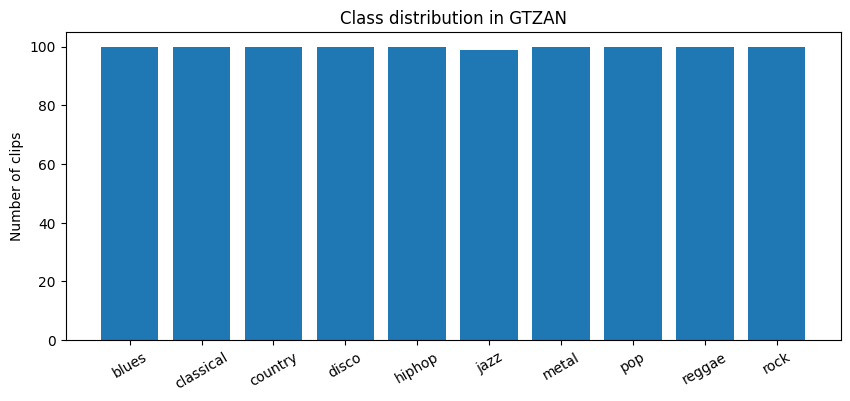

In [32]:
plt.figure(figsize=(10, 4))
unique, counts = np.unique(y, return_counts=True)
plt.bar([genres[u] for u in unique], counts)
plt.title("Class distribution in GTZAN")
plt.ylabel("Number of clips")
plt.xticks(rotation=30)
plt.savefig('figures/class_distribution.png', dpi=150)
plt.show()

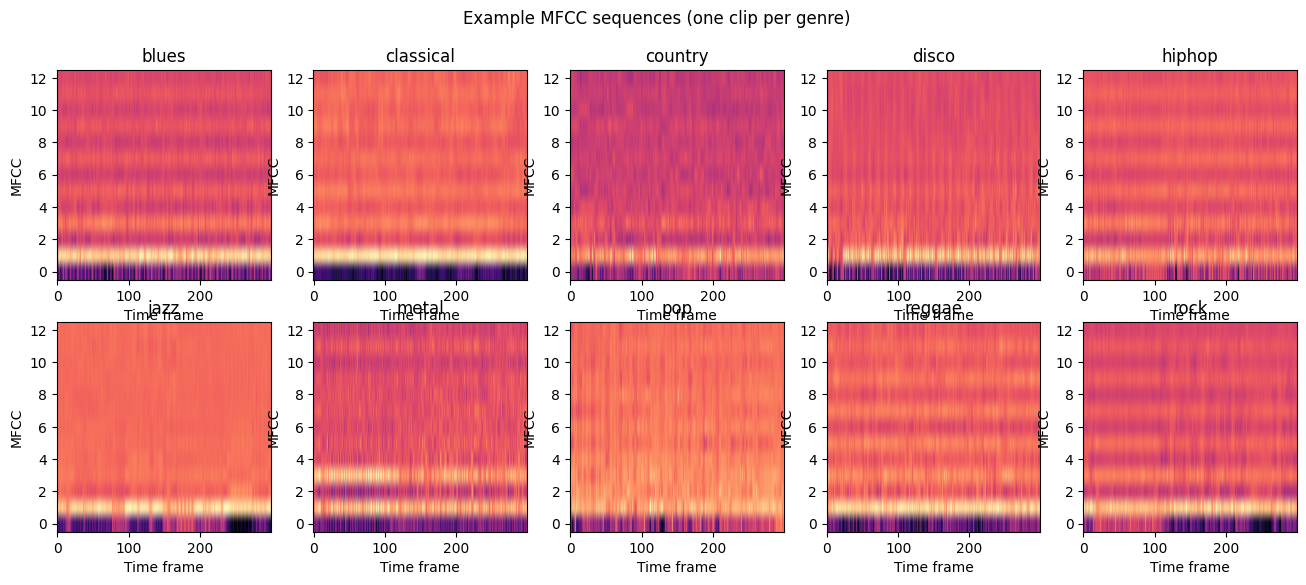

In [33]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for idx, genre in enumerate(genres):
    sample_idx = np.where(y == idx)[0][0]
    ax = axes[idx // 5, idx % 5]
    img = ax.imshow(X_seq[sample_idx].T, aspect='auto', origin='lower',cmap='magma')
    ax.set_title(genre)
    ax.set_xlabel("Time frame")
    ax.set_ylabel("MFCC")
plt.suptitle("Example MFCC sequences (one clip per genre)")
plt.savefig('figures/mfcc_examples.png', dpi=150)
plt.show()

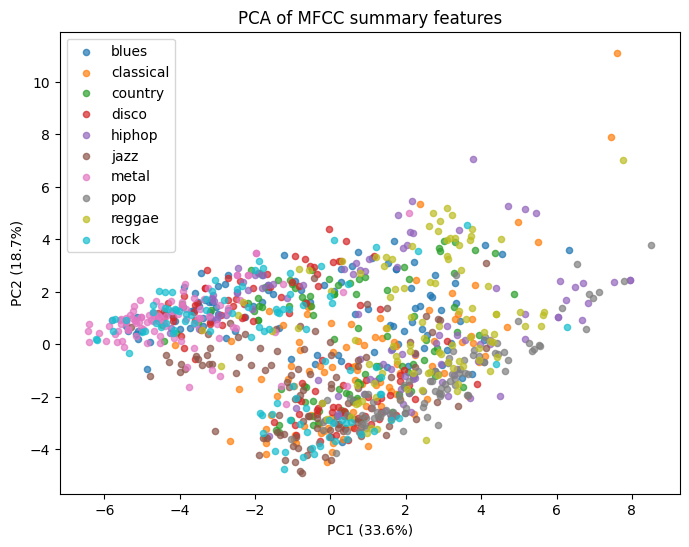

In [34]:
scaler = StandardScaler()
X_sum_scaled = scaler.fit_transform(X_sum)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sum_scaled)

plt.figure(figsize=(8, 6))
for c in range(n):
    mask = y == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],s=20, alpha=0.7, label=genres[c])
plt.legend()
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA of MFCC summary features")
plt.savefig('figures/pca_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Train / val / test split + scaling

We use a stratified 70 / 15 / 15 split. Standard scaling parameters
(mean and std) are estimated **only on the training set** to avoid
leakage. The same parameters are applied to validation and test sets.

In [35]:
X_seq_tv, X_seq_te, X_sum_tv, X_sum_te, y_tv, y_te = train_test_split(X_seq, X_sum, y, test_size=0.15, stratify=y, random_state=rng)
X_seq_tr, X_seq_va, X_sum_tr, X_sum_va, y_tr, y_va = train_test_split(X_seq_tv, X_sum_tv, y_tv, test_size=0.1765,stratify=y_tv, random_state=rng)

print(f"Train: {len(y_tr)}   Val: {len(y_va)}   Test: {len(y_te)}")

# Scale summary features
sum_scaler = StandardScaler()
X_sum_tr_s = sum_scaler.fit_transform(X_sum_tr).astype(np.float32)
X_sum_va_s = sum_scaler.transform(X_sum_va).astype(np.float32)
X_sum_te_s = sum_scaler.transform(X_sum_te).astype(np.float32)

# Scale sequence features
seq_mean = X_seq_tr.reshape(-1, nmfcc).mean(axis=0)
seq_std = X_seq_tr.reshape(-1, nmfcc).std(axis=0) + 1e-8
X_seq_tr_s = ((X_seq_tr - seq_mean) / seq_std).astype(np.float32)
X_seq_va_s = ((X_seq_va - seq_mean) / seq_std).astype(np.float32)
X_seq_te_s = ((X_seq_te - seq_mean) / seq_std).astype(np.float32)

Train: 699   Val: 150   Test: 150


## 6. K-Nearest Neighbors (from scratch)

We implement k-NN from scratch. We tune `k` on the validation set, then re-fit the model on the training and validation set after which we test on the test set.

k=  1: val acc = 0.5800
k=  3: val acc = 0.6400
k=  5: val acc = 0.6333
k=  7: val acc = 0.6133
k=  9: val acc = 0.6133
k= 11: val acc = 0.5733
k= 15: val acc = 0.5800
k= 21: val acc = 0.5867
k= 25: val acc = 0.5667

Best k = 3


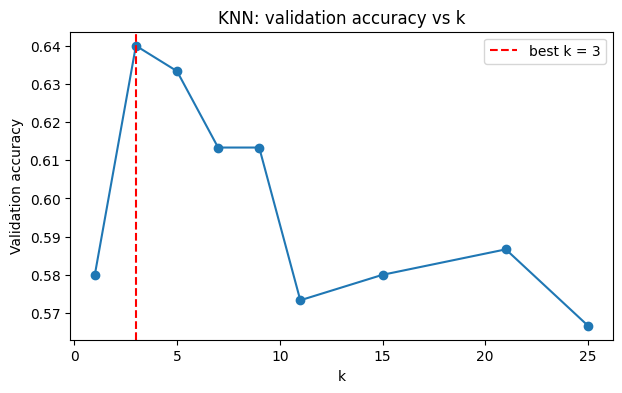


KNN test accuracy: 0.6200
KNN test macro-F1: 0.6241
              precision    recall  f1-score   support

       blues      0.889     0.533     0.667        15
   classical      0.875     0.933     0.903        15
     country      0.348     0.533     0.421        15
       disco      0.364     0.533     0.432        15
      hiphop      0.562     0.600     0.581        15
        jazz      0.765     0.867     0.812        15
       metal      0.923     0.800     0.857        15
         pop      0.625     0.667     0.645        15
      reggae      0.500     0.333     0.400        15
        rock      0.750     0.400     0.522        15

    accuracy                          0.620       150
   macro avg      0.660     0.620     0.624       150
weighted avg      0.660     0.620     0.624       150



In [36]:
class KNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.asarray(X, dtype=np.float32)
        self.y_train = np.asarray(y)

    def predict(self, X):
        X = np.asarray(X, dtype=np.float32)
        squared_test = (X ** 2).sum(axis=1, keepdims=True)        # (n_te, 1)
        squared_train = (self.X_train ** 2).sum(axis=1)           # (n_tr,)
        crossterm = X @ self.X_train.T                            # (n_te, n_tr)
        dists = np.sqrt(np.maximum(squared_test - 2 * crossterm + squared_train, 0))
        nn_idx = np.argpartition(dists, kth=self.k, axis=1)[:, :self.k]
        nn_labels = self.y_train[nn_idx]                      # (n_te, k)
        preds = np.zeros(X.shape[0], dtype=self.y_train.dtype)
        for i in range(X.shape[0]):
            vals, cnts = np.unique(nn_labels[i], return_counts=True)
            preds[i] = vals[np.argmax(cnts)]
        return preds


# Tune k on the validation set
k_values = [1, 3, 5, 7, 9, 11, 15, 21, 25]
val_accs = []
for k in k_values:
    model = KNN(k=k)
    model.fit(X_sum_tr_s, y_tr)
    pred = model.predict(X_sum_va_s)
    acc = accuracy_score(y_va, pred)
    val_accs.append(acc)
    print(f"k={k:3d}: val acc = {acc:.4f}")

best_k = k_values[int(np.argmax(val_accs))]
print(f"\nBest k = {best_k}")

# Plot validation accuracy vs k
plt.figure(figsize=(7, 4))
plt.plot(k_values, val_accs, marker='o')
plt.axvline(best_k, color='red', linestyle='--', label=f'best k = {best_k}')
plt.xlabel("k")
plt.ylabel("Validation accuracy")
plt.title("KNN: validation accuracy vs k")
plt.legend()
plt.savefig('figures/knn_k_tuning.png', dpi=150)
plt.show()

# Refit on train+val and evaluate on test
knn_final = KNN(k=best_k)
knn_final.fit(np.vstack([X_sum_tr_s, X_sum_va_s]),np.concatenate([y_tr, y_va]))
y_pred_knn = knn_final.predict(X_sum_te_s)
knn_acc = accuracy_score(y_te, y_pred_knn)
knn_f1 = f1_score(y_te, y_pred_knn, average='macro')
print(f"\nKNN test accuracy: {knn_acc:.4f}")
print(f"KNN test macro-F1: {knn_f1:.4f}")
print(classification_report(y_te, y_pred_knn,target_names=genres, digits=3))

## 7. Vanilla RNN (from scratch)

We implement the Elman RNN cell explicitly:
$$ h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h) $$
and use the last hidden state for classification:
$$ \hat{y} = W_{hy} h_T + b_y. $$

We use PyTorch tensors and `autograd` for the backward pass, but the
RNN logic is hand-written (i.e. no `nn.RNN` or `nn.RNNCell`). Gradient
clipping is used because the un-gated recurrence is prone to exploding
gradients on long sequences.

In [37]:
class VanillaRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        std_x = (1.0 / input_size) ** 0.5
        std_h = (1.0 / hidden_size) ** 0.5
        self.W_xh = nn.Parameter(torch.empty(input_size, hidden_size).uniform_(-std_x, std_x))
        self.W_hh = nn.Parameter(torch.empty(hidden_size, hidden_size).uniform_(-std_h, std_h))
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x_t, h_prev):
        return torch.tanh(x_t @ self.W_xh + h_prev @ self.W_hh + self.b_h)


class VanillaRNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = VanillaRNNCell(input_size, hidden_size)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        B, T, _ = x.shape
        h = torch.zeros(B, self.hidden_size, device=x.device)
        for t in range(T):
            h = self.cell(x[:, t, :], h)
        return self.fc(h)

In [38]:
def make_loader(X, y, batch_size=32, shuffle=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t),batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_loader, val_loader, epochs, lr,grad_clip=None, weight_decay=0.0, name="model",patience=15):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=5)
    crit = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [], 'val_acc': []}
    best_val_acc, best_state = 0.0, None
    epochs_no_improve = 0

    for ep in range(epochs):
        model.train()
        tl, tc, tn = 0.0, 0, 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            opt.zero_grad()
            out = model(Xb)
            loss = crit(out, yb)
            loss.backward()
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()
            tl += loss.item() * Xb.size(0)
            tc += (out.argmax(1) == yb).sum().item()
            tn += Xb.size(0)
        model.eval()
        vl, vc, vn = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                out = model(Xb)
                loss = crit(out, yb)
                vl += loss.item() * Xb.size(0)
                vc += (out.argmax(1) == yb).sum().item()
                vn += Xb.size(0)

        tr_loss = tl / tn;  val_loss = vl / vn
        tr_acc  = tc / tn;  val_acc  = vc / vn
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(val_acc)

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (ep + 1) % 5 == 0 or ep == 0:
            print(f"[{name}] epoch {ep+1:3d}  "
                  f"train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}  "
                  f"train_acc={tr_acc:.4f}  val_acc={val_acc:.4f}")

        if epochs_no_improve >= patience:
            print(f"[{name}] Early stopping at epoch {ep+1} "
                  f"(best val_acc={best_val_acc:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


def evaluate(model, loader):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb = Xb.to(device)
            out = model(Xb)
            all_pred.append(out.argmax(1).cpu().numpy())
            all_true.append(yb.numpy())
    return np.concatenate(all_true), np.concatenate(all_pred)


def plot_history(history, title, savepath):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    ep_ax = range(1, len(history['train_loss']) + 1)
    axes[0].plot(ep_ax, history['train_loss'], label='train')
    axes[0].plot(ep_ax, history['val_loss'],   label='val')
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].set_title(f"{title}: loss"); axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[1].plot(ep_ax, history['train_acc'], label='train')
    axes[1].plot(ep_ax, history['val_acc'],   label='val')
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"{title}: accuracy"); axes[1].legend()
    axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(savepath, dpi=150)
    plt.show()


Training the Vanilla RNN
Vanilla RNN parameter count: 19,466
[VanillaRNN] epoch   1  train_loss=2.0757  val_loss=1.9188  train_acc=0.2761  val_acc=0.3133
[VanillaRNN] epoch   5  train_loss=1.5170  val_loss=1.6676  train_acc=0.4821  val_acc=0.4667
[VanillaRNN] epoch  10  train_loss=1.2783  val_loss=1.5723  train_acc=0.5794  val_acc=0.4867
[VanillaRNN] epoch  15  train_loss=1.0937  val_loss=1.5625  train_acc=0.6567  val_acc=0.4867
[VanillaRNN] epoch  20  train_loss=0.9182  val_loss=1.6185  train_acc=0.7067  val_acc=0.4800
[VanillaRNN] epoch  25  train_loss=0.7994  val_loss=1.6300  train_acc=0.7554  val_acc=0.4800
[VanillaRNN] Early stopping at epoch 26 (best val_acc=0.5200)


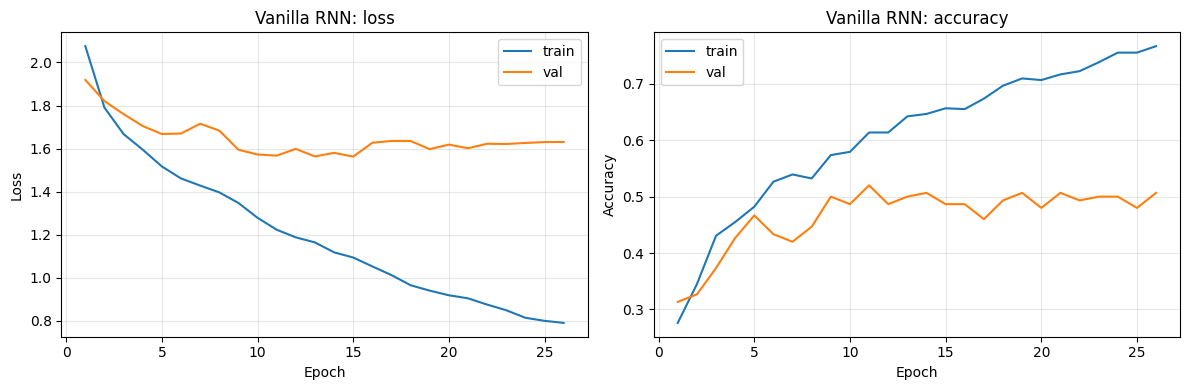


Vanilla RNN test accuracy: 0.4267
Vanilla RNN test macro-F1: 0.4004
              precision    recall  f1-score   support

       blues      0.278     0.333     0.303        15
   classical      0.765     0.867     0.812        15
     country      0.400     0.267     0.320        15
       disco      0.235     0.267     0.250        15
      hiphop      0.333     0.200     0.250        15
        jazz      0.625     0.333     0.435        15
       metal      0.545     0.800     0.649        15
         pop      0.400     0.667     0.500        15
      reggae      0.444     0.533     0.485        15
        rock      0.000     0.000     0.000        15

    accuracy                          0.427       150
   macro avg      0.403     0.427     0.400       150
weighted avg      0.403     0.427     0.400       150



In [39]:
BATCH_SIZE = 32
train_loader = make_loader(X_seq_tr_s, y_tr, BATCH_SIZE, shuffle=True)
val_loader = make_loader(X_seq_va_s, y_va, BATCH_SIZE)
test_loader = make_loader(X_seq_te_s, y_te, BATCH_SIZE)

print("Training the Vanilla RNN")
vanilla_rnn = VanillaRNN(input_size=nmfcc, hidden_size=128,num_classes=n)
n_params = sum(p.numel() for p in vanilla_rnn.parameters())
print(f"Vanilla RNN parameter count: {n_params:,}")

vanilla_rnn, hist_vanilla = train_model(vanilla_rnn, train_loader, val_loader,epochs=40, lr=1e-3, grad_clip=5.0, weight_decay=1e-5,name="VanillaRNN")

plot_history(hist_vanilla, "Vanilla RNN","figures/training_curves_vanilla.png")

y_true_v, y_pred_v = evaluate(vanilla_rnn, test_loader)
vanilla_acc = accuracy_score(y_true_v, y_pred_v)
vanilla_f1 = f1_score(y_true_v, y_pred_v, average='macro')
print(f"\nVanilla RNN test accuracy: {vanilla_acc:.4f}")
print(f"Vanilla RNN test macro-F1: {vanilla_f1:.4f}")
print(classification_report(y_true_v, y_pred_v,
                            target_names=genres, digits=3))

## 8. Bidirectional LSTM (PyTorch)


Training the Multi-Head Attention Bi-LSTM
Parameter count: 284,684
[BiLSTM] epoch   1  train_loss=2.0407  val_loss=2.0435  train_acc=0.2890  val_acc=0.4000
[BiLSTM] epoch   5  train_loss=1.3685  val_loss=1.1718  train_acc=0.5179  val_acc=0.6333
[BiLSTM] epoch  10  train_loss=1.1212  val_loss=1.0022  train_acc=0.6195  val_acc=0.7067
[BiLSTM] epoch  15  train_loss=0.9565  val_loss=0.9225  train_acc=0.6509  val_acc=0.7200
[BiLSTM] epoch  20  train_loss=0.7342  val_loss=0.8918  train_acc=0.7454  val_acc=0.7067
[BiLSTM] epoch  25  train_loss=0.5993  val_loss=0.9128  train_acc=0.8026  val_acc=0.7067
[BiLSTM] epoch  30  train_loss=0.4813  val_loss=0.8854  train_acc=0.8455  val_acc=0.7200
[BiLSTM] epoch  35  train_loss=0.4405  val_loss=0.9312  train_acc=0.8469  val_acc=0.6667
[BiLSTM] epoch  40  train_loss=0.3977  val_loss=0.9412  train_acc=0.8755  val_acc=0.6933
[BiLSTM] Early stopping at epoch 44 (best val_acc=0.7267)


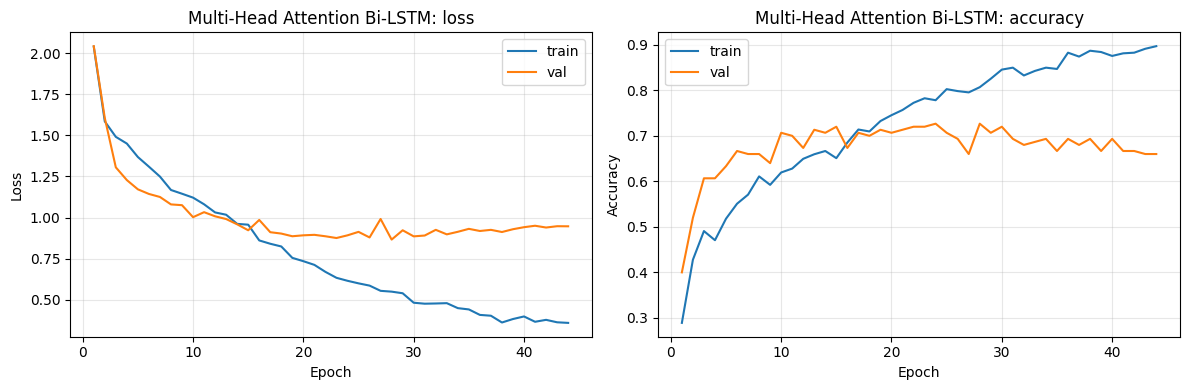


Multi-Head Attention Bi-LSTM  test acc=0.6533  macro-F1=0.6474
              precision    recall  f1-score   support

       blues      0.786     0.733     0.759        15
   classical      1.000     0.800     0.889        15
     country      0.625     0.667     0.645        15
       disco      0.538     0.467     0.500        15
      hiphop      0.500     0.400     0.444        15
        jazz      0.750     1.000     0.857        15
       metal      0.786     0.733     0.759        15
         pop      0.650     0.867     0.743        15
      reggae      0.533     0.533     0.533        15
        rock      0.357     0.333     0.345        15

    accuracy                          0.653       150
   macro avg      0.653     0.653     0.647       150
weighted avg      0.653     0.653     0.647       150



In [40]:
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_size, n_heads=2):
        super().__init__()
        self.heads = nn.ModuleList([nn.Sequential(nn.Linear(hidden_size, hidden_size), nn.Tanh(),nn.Linear(hidden_size, 1))
            for _ in range(n_heads)
        ])

    def forward(self, h):
        contexts = []
        for head in self.heads:
            alpha = torch.softmax(head(h), dim=1)  # (B, T, 1)
            contexts.append((alpha * h).sum(dim=1)) # (B, H)
        return torch.cat(contexts, dim=1)           # (B, n_heads*H)


class AttentionBiLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes,
                 n_heads=2, dropout=0.5):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size,
                            num_layers=1,
                            batch_first=True,
                            bidirectional=True)
        self.attention = MultiHeadAttention(hidden_size * 2, n_heads)
        self.bn   = nn.BatchNorm1d(hidden_size * 2 * n_heads)
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(hidden_size * 2 * n_heads, num_classes)

    def forward(self, x):
        h_all, _ = self.lstm(x)              # (B, T, 2*H)
        context  = self.attention(h_all)     # (B, n_heads*2*H)
        return self.fc(self.drop(self.bn(context)))


print("Training the Multi-Head Attention Bi-LSTM")
lstm_model = AttentionBiLSTM(input_size=nmfcc, hidden_size=128, num_classes=n, n_heads=2, dropout=0.5)
print(f"Parameter count: "f"{sum(p.numel() for p in lstm_model.parameters()):,}")

lstm_model, hist_lstm = train_model(lstm_model, train_loader, val_loader,epochs=150, lr=5e-4, grad_clip=5.0, weight_decay=1e-3,name="BiLSTM", patience=20)

plot_history(hist_lstm, "Multi-Head Attention Bi-LSTM", "figures/training_curves_lstm.png")

y_true_l, y_pred_l = evaluate(lstm_model, test_loader)
lstm_acc = accuracy_score(y_true_l, y_pred_l)
lstm_f1  = f1_score(y_true_l, y_pred_l, average='macro')
print(f"\nMulti-Head Attention Bi-LSTM  test acc={lstm_acc:.4f}  macro-F1={lstm_f1:.4f}")
print(classification_report(y_true_l, y_pred_l,target_names=genres, digits=3))

## 9. Comparison and confusion matrices

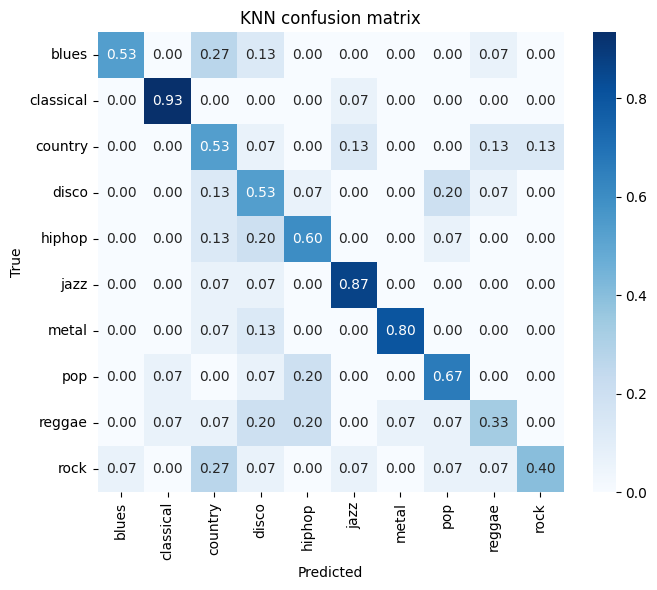

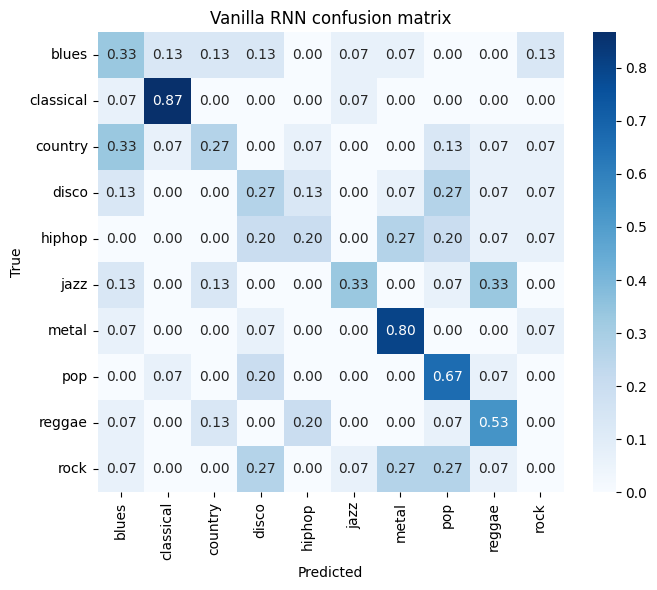

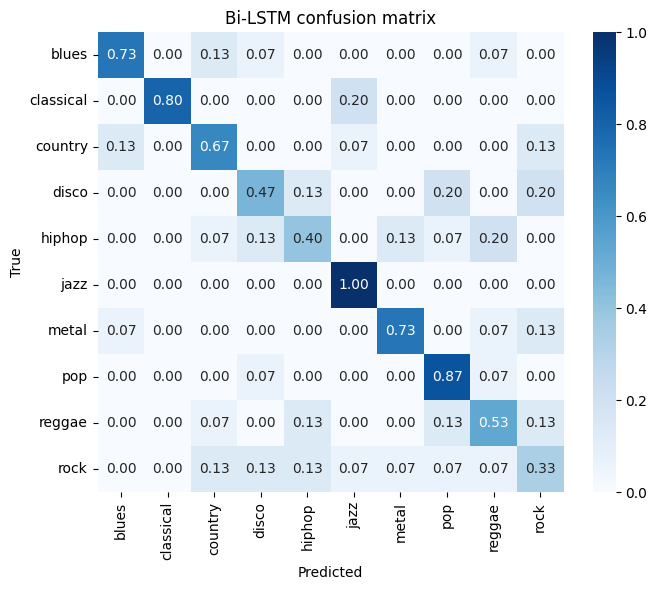

In [41]:
def plot_confusion(y_true, y_pred, title, savepath):
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',xticklabels=genres, yticklabels=genres)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(savepath, dpi=150)
    plt.show()

plot_confusion(y_te, y_pred_knn, "KNN confusion matrix","figures/confusion_knn.png")
plot_confusion(y_true_v, y_pred_v,"Vanilla RNN confusion matrix","figures/confusion_vanilla.png")
plot_confusion(y_true_l, y_pred_l,"Bi-LSTM confusion matrix","figures/confusion_lstm.png")

                     Model  Accuracy  Macro F1
        KNN (from scratch)    0.6200    0.6241
Vanilla RNN (from scratch)    0.4267    0.4004
         Bi-LSTM (PyTorch)    0.6533    0.6474


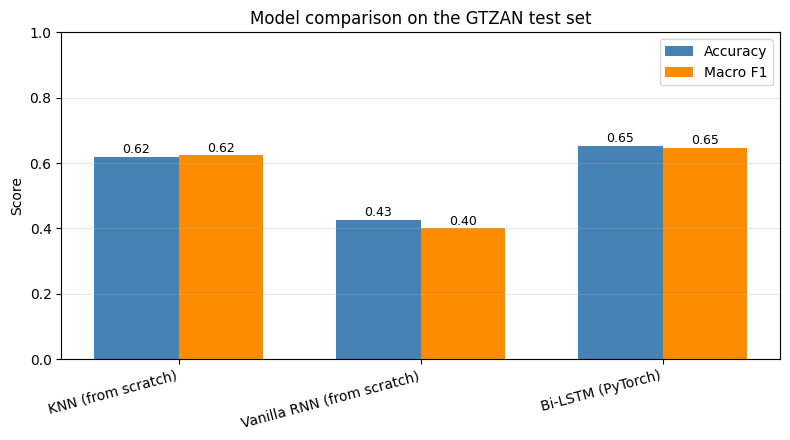

In [42]:
results_df = pd.DataFrame({
    'Model':    ['KNN (from scratch)',
                 'Vanilla RNN (from scratch)',
                 'Bi-LSTM (PyTorch)'],
    'Accuracy': [knn_acc, vanilla_acc, lstm_acc],
    'Macro F1': [knn_f1, vanilla_f1, lstm_f1],
})
print(results_df.to_string(index=False, float_format='%.4f'))

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(results_df))
w = 0.35
ax.bar(x - w / 2, results_df['Accuracy'], w, label='Accuracy',
       color='steelblue')
ax.bar(x + w / 2, results_df['Macro F1'], w, label='Macro F1',
       color='darkorange')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model comparison on the GTZAN test set")
ax.legend()
ax.grid(alpha=0.3, axis='y')
for i, (a, f) in enumerate(zip(results_df['Accuracy'],
                               results_df['Macro F1'])):
    ax.text(i - w / 2, a + 0.01, f"{a:.2f}", ha='center', fontsize=9)
    ax.text(i + w / 2, f + 0.01, f"{f:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('figures/model_comparison.png', dpi=150)
plt.show()

## 10. Diagnostic: hidden-state magnitude over time

We look at how the gradient norm of the loss with respect to the hidden state at each time step
decays as we move backwards through time.

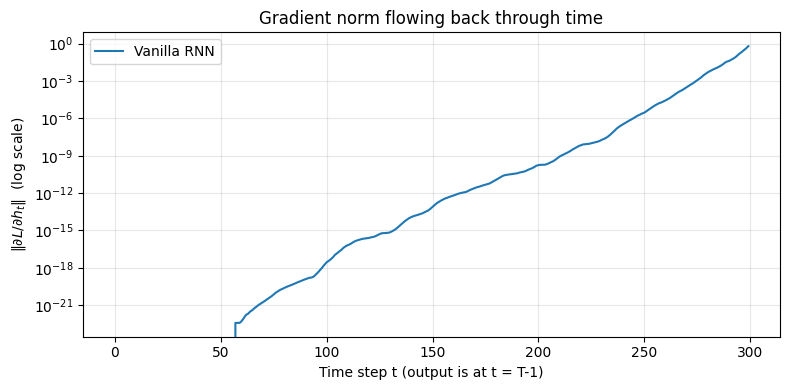

In [46]:
def gradient_norm_over_time(model, sample):
    model.eval()
    x = torch.tensor(sample[None], dtype=torch.float32, device=device)
    T = x.size(1)

    cell = model.cell
    h = torch.zeros(1, cell.hidden_size, device=device)
    h_history = []
    for t in range(T):
        h = cell(x[:, t, :], h)
        h.retain_grad()
        h_history.append(h)
    logits = model.fc(h)

    target = torch.tensor([0], device=device)
    loss = nn.CrossEntropyLoss()(logits, target)
    loss.backward()

    norms = []
    for h_t in h_history:
        if h_t.grad is None:
            norms.append(0.0)
        else:
            norms.append(h_t.grad.norm().item())
    return norms


sample = X_seq_va_s[0]
norms_vanilla = gradient_norm_over_time(vanilla_rnn, sample)

plt.figure(figsize=(8, 4))
plt.semilogy(range(maxlen), norms_vanilla, label='Vanilla RNN')
plt.xlabel("Time step t (output is at t = T-1)")
plt.ylabel(r"$\|\partial L / \partial h_t\|$  (log scale)")
plt.title("Gradient norm flowing back through time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/gradient_flow.png', dpi=150)
plt.show()